# Module 1.3: Backpropagation From Scratch

In Module 0.2 you trained a network by calling `loss.backward()` — and magic happened. In this module we **open the box**. You will compute every gradient of a real neural network **by hand, in raw NumPy** (NumPy has no autograd, so there is nowhere to hide), and then prove your math is right in two independent ways:

1. **Finite differences** — measure the slope numerically, with a "ruler".
2. **PyTorch agrees** — write the *identical* network in PyTorch and check that `loss.backward()` produces the *exact same numbers* your hand-derived code does.

Finally, you'll write the two most famous optimizers — **SGD** and **Adam** — from scratch, and watch them learn.

After this module, autograd is a *convenience*, not a mystery. And when a loss refuses to fall in Module 5, you will know exactly what machinery is (or isn't) moving.

## 1. The Gradient, Measured with a Ruler

### The Concept
A gradient answers one question per weight: *"if I nudge this weight up by a hair, does the loss go up or down — and how fast?"*

You don't need calculus to answer that. You can literally **nudge the weight and re-measure the loss**:

$$\frac{\partial L}{\partial w} \approx \frac{L(w + h) - L(w - h)}{2h} \quad \text{for a tiny } h$$

This is called a **(central) finite difference**.

### Why?
Because it's *ground truth*. It's far too slow to train with — one weight per forward pass means a 7B-parameter model would need 14 **billion** forward passes for a single step — but it is the perfect **lie detector** for checking fast analytic gradients. Real deep-learning frameworks are tested against exactly this.

In [1]:
import numpy as np

np.random.seed(0)  # reproducibility: same random numbers every run

# The simplest possible "model": one weight. prediction = w * x
x_val, y_val = 3.0, 2.0

def tiny_loss(w):
    pred = w * x_val
    return (pred - y_val) ** 2   # squared error

w = 0.5

# METHOD 1 — Calculus (chain rule, by hand):
#   L = (w*x - y)^2   =>   dL/dw = 2 * (w*x - y) * x
analytic = 2 * (w * x_val - y_val) * x_val

# METHOD 2 — The ruler (nudge and re-measure):
h = 1e-5
numeric = (tiny_loss(w + h) - tiny_loss(w - h)) / (2 * h)

print(f"Analytic gradient (chain rule): {analytic:.8f}")
print(f"Numeric gradient (the ruler):   {numeric:.8f}")
print(f"Difference: {abs(analytic - numeric):.2e}  <- agreement to ~10 decimal places")

Analytic gradient (chain rule): -3.00000000
Numeric gradient (the ruler):   -3.00000000
Difference: 1.23e-11  <- agreement to ~10 decimal places


## 2. The Chain Rule = An Assembly Line in Reverse

### The Analogy (Blame Flows Backward)
Picture a factory line: **Station 1** (Linear) → **Station 2** (ReLU) → **Station 3** (Linear) → **the Inspector** (Loss). The inspector finds a defect in the final product. She doesn't need to understand the whole factory — she tells Station 3 exactly how much *its* output contributed to the defect. Station 3 looks at its own recipe, works out how much of that blame belongs to *its* inputs, and passes it back to Station 2. And so on, all the way to the front door.

That's backpropagation: **each layer only needs its own local derivative, plus the blame arriving from the layer after it.**

### The Math
We'll use the *exact* network you trained in Module 0.2 — the sine-fitter — just one hidden layer to keep the algebra visible ($x$ is $(N,1)$, hidden width 16):

$$z_1 = x W_1 + b_1 \qquad h = \mathrm{ReLU}(z_1) \qquad \hat{y} = h W_2 + b_2 \qquad L = \tfrac{1}{N}\sum (\hat{y} - y)^2$$

Walking backward, station by station (each line is one application of the chain rule):

| Blame for... | Formula | Shape | Intuition |
|---|---|---|---|
| $\hat{y}$ | $\partial L/\partial \hat{y} = \tfrac{2}{N}(\hat{y} - y)$ | $(N,1)$ | how wrong, per example |
| $W_2$ | $h^\top \, \partial L/\partial \hat{y}$ | $(16,1)$ | active neurons soak up blame |
| $b_2$ | column-sum of $\partial L/\partial \hat{y}$ | $(1,)$ | bias touched every example |
| $h$ | $\partial L/\partial \hat{y} \; W_2^\top$ | $(N,16)$ | blame routed back through the same wires |
| $z_1$ | $\partial L/\partial h \odot \mathbb{1}[z_1 > 0]$ | $(N,16)$ | ReLU's gate: a neuron that was *off* gets **zero** blame |
| $W_1$ | $x^\top \, \partial L/\partial z_1$ | $(1,16)$ | same pattern as $W_2$ |
| $b_1$ | column-sum of $\partial L/\partial z_1$ | $(16,)$ | same pattern as $b_2$ |

Two things to burn in:
- **The transposes are not decoration.** $y = xW$ sends signals *forward* through $W$; blame travels *backward* through the same wiring, which is exactly multiplication by $W^\top$. (Check the shapes in the table — they only work out one way.)
- **Every gradient has the same shape as the thing it's the gradient *of*.** If `dW1.shape != W1.shape`, you have a bug. This is the #1 sanity check.

In [2]:
# The same sine-fitting task as Module 0.2 -- but in raw NumPy this time.
N = 100
x = np.linspace(-3, 3, N).reshape(N, 1)   # (100, 1) inputs
y = np.sin(x)                              # (100, 1) targets

# Parameters of a 1 -> 16 -> 1 network.
rng = np.random.default_rng(0)
W1 = rng.normal(0, 0.5, size=(1, 16)); b1 = np.zeros(16)
W2 = rng.normal(0, 0.5, size=(16, 1)); b2 = np.zeros(1)

def forward(x):
    z1 = x @ W1 + b1              # Station 1: Linear
    h = np.maximum(z1, 0.0)       # Station 2: ReLU
    y_hat = h @ W2 + b2           # Station 3: Linear
    return z1, h, y_hat           # keep the intermediates -- backward needs them!

z1, h, y_hat = forward(x)
loss = ((y_hat - y) ** 2).mean()
print(f"Untrained loss: {loss:.4f}")
print("(Note that forward() RETURNS its intermediates z1 and h.")
print(" Backprop must replay the assembly line, so every station's output is kept.")
print(" This is exactly the memory autograd quietly spends on its 'graph'.)")

Untrained loss: 0.3687
(Note that forward() RETURNS its intermediates z1 and h.
 Backprop must replay the assembly line, so every station's output is kept.
 This is exactly the memory autograd quietly spends on its 'graph'.)


## 3. The Backward Pass, By Hand

Here is the entire table above, as seven lines of NumPy. Read it top to bottom as *blame flowing backward through the factory*.

In [3]:
def backward(x, y, z1, h, y_hat):
    N = x.shape[0]
    d_yhat = 2.0 * (y_hat - y) / N        # the Inspector's report
    dW2 = h.T @ d_yhat                    # blame for W2   (16,1)
    db2 = d_yhat.sum(axis=0)              # blame for b2   (1,)
    dh = d_yhat @ W2.T                    # pass blame back through W2's wires  (N,16)
    dz1 = dh * (z1 > 0)                   # ReLU gate: neurons that were OFF get zero blame
    dW1 = x.T @ dz1                       # blame for W1   (1,16)
    db1 = dz1.sum(axis=0)                 # blame for b1   (16,)
    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

grads = backward(x, y, z1, h, y_hat)

params = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
print("Sanity check #1: every gradient has the SAME SHAPE as its parameter:")
for name in params:
    print(f"  {name}: param {str(params[name].shape):>8}  grad {str(grads[name].shape):>8}"
          f"   match: {params[name].shape == grads[name].shape}")

Sanity check #1: every gradient has the SAME SHAPE as its parameter:
  W1: param  (1, 16)  grad  (1, 16)   match: True
  b1: param    (16,)  grad    (16,)   match: True
  W2: param  (16, 1)  grad  (16, 1)   match: True
  b2: param     (1,)  grad     (1,)   match: True


## 4. Checkpoint #1 — The Ruler Agrees

Now the moment of truth. We nudge a handful of randomly-chosen individual weights (a few per matrix), measure the slope with finite differences, and compare against our hand-derived formulas. If any formula above is wrong — a missing transpose, a forgotten ReLU mask, a dropped $\tfrac{2}{N}$ — this check will scream.

In [4]:
def loss_at():
    _, _, y_hat = forward(x)
    return ((y_hat - y) ** 2).mean()

h_step = 1e-6
worst = 0.0
for name, P in params.items():
    flat = P.reshape(-1)
    for idx in rng.choice(flat.size, size=min(5, flat.size), replace=False):
        orig = flat[idx]
        flat[idx] = orig + h_step; L_plus = loss_at()
        flat[idx] = orig - h_step; L_minus = loss_at()
        flat[idx] = orig                          # restore!
        numeric = (L_plus - L_minus) / (2 * h_step)
        analytic = grads[name].reshape(-1)[idx]
        worst = max(worst, abs(numeric - analytic))

print(f"Largest disagreement across all spot-checks: {worst:.2e}")
assert worst < 1e-7, "Backward pass has a bug!"
print("PASSED. Your hand-derived backward pass matches physical reality.")

Largest disagreement across all spot-checks: 6.37e-11
PASSED. Your hand-derived backward pass matches physical reality.


## 5. Checkpoint #2 — PyTorch Agrees, to the Decimal

One more proof, from the opposite direction: we write the *same* forward pass in PyTorch, starting from the *same* weights, and let autograd differentiate it. If backprop is what we claimed, `loss.backward()` must fill each `.grad` with **the numbers your NumPy code just computed**.

In [5]:
import torch

# Leaf tensors initialized from OUR NumPy weights (float64, so we can demand exactness).
W1_t = torch.tensor(W1, requires_grad=True)
b1_t = torch.tensor(b1, requires_grad=True)
W2_t = torch.tensor(W2, requires_grad=True)
b2_t = torch.tensor(b2, requires_grad=True)
x_t, y_t = torch.tensor(x), torch.tensor(y)

# The identical forward pass, in torch ops.
z1_t = x_t @ W1_t + b1_t
h_t = torch.relu(z1_t)
y_hat_t = h_t @ W2_t + b2_t
loss_t = ((y_hat_t - y_t) ** 2).mean()

loss_t.backward()   # <-- the "magic" we are demystifying

for name, tensor in [("W1", W1_t), ("b1", b1_t), ("W2", W2_t), ("b2", b2_t)]:
    same = np.allclose(tensor.grad.numpy(), grads[name], atol=1e-12)
    print(f"autograd d{name} == your d{name}?  {same}")

print("\nThat is ALL loss.backward() does: your seven lines, generalized to every")
print("operation PyTorch knows, applied automatically along the recorded graph.")

autograd dW1 == your dW1?  True
autograd db1 == your db1?  True
autograd dW2 == your dW2?  True
autograd db2 == your db2?  True

That is ALL loss.backward() does: your seven lines, generalized to every
operation PyTorch knows, applied automatically along the recorded graph.


## 6. Gradient Descent From Scratch

### The Concept
We have trustworthy gradients. Training is now embarrassingly simple — the four sacred moves from Module 0.2, with **no** `torch.optim` in sight:

1. **Forward** — run the assembly line.
2. **Backward** — collect the blame (your function!).
3. **Step** — nudge every weight *against* its gradient: $w \mathrel{-}= \eta \cdot \nabla_w L$.
4. Repeat.

The step size $\eta$ is the **learning rate** — the same knob you'll tune (and occasionally blow up) for the rest of the course.

step    0 | loss 0.36872


step  500 | loss 0.01142
step 1000 | loss 0.00300
step 1500 | loss 0.00169
step 2000 | loss 0.00129
step 2500 | loss 0.00103
step 2999 | loss 0.00092


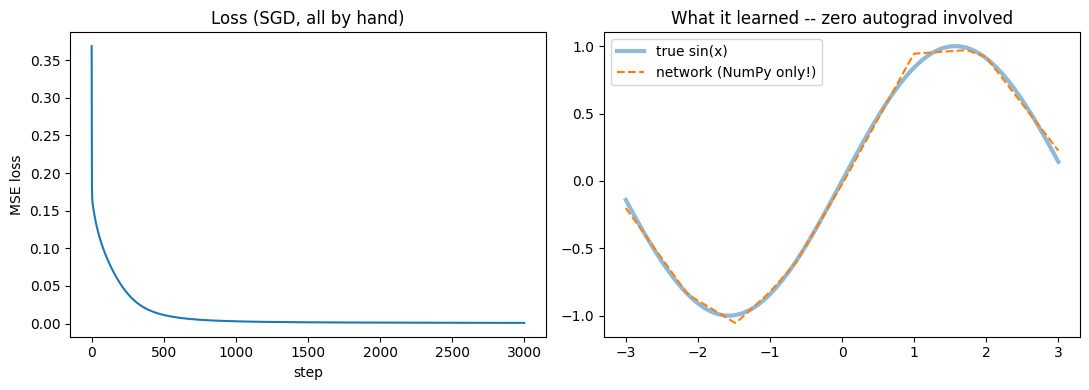

In [6]:
import matplotlib.pyplot as plt

# Fresh weights so we can watch learning from zero.
rng = np.random.default_rng(0)
W1 = rng.normal(0, 0.5, size=(1, 16)); b1 = np.zeros(16)
W2 = rng.normal(0, 0.5, size=(16, 1)); b2 = np.zeros(1)
lr = 0.05

sgd_history = []
for step in range(3000):
    z1, h, y_hat = forward(x)                       # 1. FORWARD
    loss = ((y_hat - y) ** 2).mean()
    sgd_history.append(loss)
    g = backward(x, y, z1, h, y_hat)                # 2. BACKWARD (yours!)
    W1 -= lr * g["W1"]; b1 -= lr * g["b1"]          # 3. STEP (this IS the optimizer)
    W2 -= lr * g["W2"]; b2 -= lr * g["b2"]
    if step % 500 == 0 or step == 2999:
        print(f"step {step:4d} | loss {loss:.5f}")

_, _, y_learned = forward(x)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(sgd_history); ax1.set_title("Loss (SGD, all by hand)")
ax1.set_xlabel("step"); ax1.set_ylabel("MSE loss")
ax2.plot(x, y, linewidth=3, alpha=0.5, label="true sin(x)")
ax2.plot(x, y_learned, linestyle="--", label="network (NumPy only!)")
ax2.legend(); ax2.set_title("What it learned -- zero autograd involved")
plt.tight_layout(); plt.show()

## 7. Adam From Scratch

### The Concept
Raw SGD treats every weight identically. **Adam** keeps two running averages *per weight* and uses them to give each weight its own effective step size:

1. **First moment $m$ (momentum):** running average of the gradient. Consistent direction → builds speed.
2. **Second moment $v$:** running average of the *squared* gradient. The update is divided by $\sqrt{v}$, so weights with big noisy gradients take calm steps and weights with tiny gradients get a relative boost.
3. **Bias correction:** $m$ and $v$ start at zero, so early estimates are too small; dividing by $(1-\beta^t)$ un-shrinks them.

$$m \leftarrow \beta_1 m + (1-\beta_1) g \qquad v \leftarrow \beta_2 v + (1-\beta_2) g^2 \qquad w \mathrel{-}= \eta \, \frac{\hat m}{\sqrt{\hat v} + \epsilon}$$

That's the entire optimizer that trains every modern LLM (plus weight decay — the "W" in AdamW, which we meet in Module 5.2). Here it is in ~15 lines.

final loss  SGD : 0.00092
final loss  Adam: 0.00014


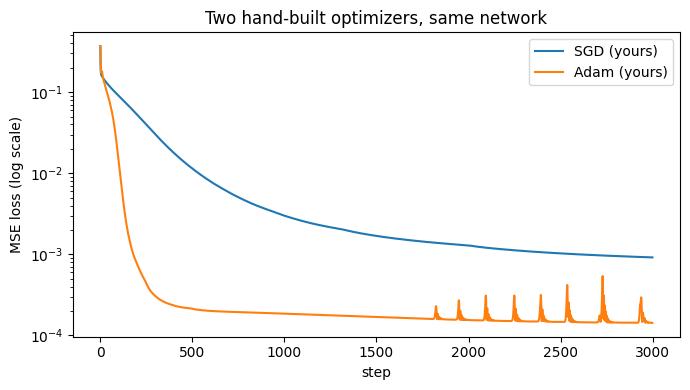

In [7]:
# Fresh weights again, identical starting point to the SGD run.
rng = np.random.default_rng(0)
W1 = rng.normal(0, 0.5, size=(1, 16)); b1 = np.zeros(16)
W2 = rng.normal(0, 0.5, size=(16, 1)); b2 = np.zeros(1)

lr, beta1, beta2, eps = 0.01, 0.9, 0.999, 1e-8
params = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
m = {k: np.zeros_like(v) for k, v in params.items()}   # first moment (momentum)
v = {k: np.zeros_like(p) for k, p in params.items()}   # second moment (RMS)

adam_history = []
for step in range(1, 3001):
    z1, h, y_hat = forward(x)
    adam_history.append(((y_hat - y) ** 2).mean())
    g = backward(x, y, z1, h, y_hat)
    for k in params:
        m[k] = beta1 * m[k] + (1 - beta1) * g[k]           # momentum update
        v[k] = beta2 * v[k] + (1 - beta2) * g[k] ** 2      # RMS update
        m_hat = m[k] / (1 - beta1 ** step)                 # bias correction
        v_hat = v[k] / (1 - beta2 ** step)
        params[k] -= lr * m_hat / (np.sqrt(v_hat) + eps)   # the Adam step

print(f"final loss  SGD : {sgd_history[-1]:.5f}")
print(f"final loss  Adam: {adam_history[-1]:.5f}")

plt.figure(figsize=(7, 4))
plt.plot(sgd_history, label="SGD (yours)")
plt.plot(adam_history, label="Adam (yours)")
plt.yscale("log"); plt.xlabel("step"); plt.ylabel("MSE loss (log scale)")
plt.title("Two hand-built optimizers, same network")
plt.legend(); plt.tight_layout(); plt.show()

## 8. Handing the Wheel Back to Autograd

From the next module onward we go back to writing `loss.backward()` and `torch.optim.AdamW(...)` — but the relationship has changed. You now know that:

- **`loss.backward()`** = your `backward()` function, generalized to every operation in the graph. Same chain rule, same transposes, same ReLU-style gates.
- **`optimizer.step()`** = your update loop. `torch.optim.SGD` is Section 6; `torch.optim.Adam` is Section 7, verbatim.
- **The memory autograd uses** = the intermediates (`z1`, `h`) your `forward()` had to keep.

When training misbehaves later (Module 5.4 is an entire clinic on this), you can reason about *which part of this machinery* is failing — because you've built every part of it.

### 🏋️ Try it yourself

1. **The lie detector in action.** Sabotage `backward()`: change the ReLU gate from `(z1 > 0)` to `(z1 > 1)` and re-run Checkpoint #1. Watch the finite-difference check catch the bug instantly. This trick — *check a hand-written gradient against a numerical one* — will serve you for the rest of your career.
2. **Go deeper.** Add a second hidden layer (16 → 16). You only need two more lines in `backward()` — notice how the blame-routing pattern (`@ W.T`, then gate) just repeats.
3. **Adam's knobs.** Set `beta1 = 0.5` (jumpy momentum) and re-run. How does the loss curve change? What about `beta2 = 0.9`?

In [8]:
# Starter for Task 1: copy of backward() with the sabotaged ReLU gate.
def backward_broken(x, y, z1, h, y_hat):
    N = x.shape[0]
    d_yhat = 2.0 * (y_hat - y) / N
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (z1 > 1)          # <-- THE BUG: should be (z1 > 0)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)
    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

z1, h, y_hat = forward(x)
bad_grads = backward_broken(x, y, z1, h, y_hat)
good_grads = backward(x, y, z1, h, y_hat)

# Compare the two on W1 -- then re-run the Checkpoint #1 loop with bad_grads
# in place of `grads` and watch the assertion fire.
print("max |good - bad| on dW1:", np.abs(good_grads["W1"] - bad_grads["W1"]).max())

max |good - bad| on dW1: 0.0016295193943916396
